# Exploratory Notebook (Illustrative Purposes)

The first half of this notebook showcases some of the exploratory procedures that (e.g. modifying and understanding particular aspects of the utilised libraries and codebases). As such, the first half is prior to hypothesis formation.

The second half of this notebook aims to provide suplementary materials that help augment our discussions within the paper. For instance, as at least one of the stated hypotheses was proven false, we are motivated to try and understand why this may be the case. While we offer at least one (seemingly) obvious explaination within our discussion (i.e. the model is adequately capturing the syntactic language properties of the given data and the additional PoS/DepRel tags may simply be introducing noise; or prividing minimal benefit), we outline data issues which may be contributing to why the proposed methods may not be as performant as we had originally hoped.

## Notebook Sections:

1. Boilerplate
2. Investigating the tokenisation process
3. Visualisation regarding the distribution of PoS and DepRel taggings

# 1. Boilerplate

In [1]:
from tqdm import tqdm
import ujson as json
import sys
import os

In [2]:
sys.path.insert(0, '../models/RE_improved_baseline');
from transformers import AutoConfig, AutoTokenizer
from prepro import TACREDProcessor, RETACREDProcessor, Processor
from prepro import convert_token

In [3]:
train_file = os.path.join("./train_examples.json");
dev_file = os.path.join("./dev_examples.json");
test_file = os.path.join("./test_examples.json");

In [4]:
with open(train_file, "r") as target_train_file:
    train_samples = json.load(target_train_file)

with open(train_file, "r") as target_dev_file:
    dev_samples = json.load(target_dev_file)

with open(test_file, "r") as target_test_file:
    test_samples = json.load(target_test_file)

In [5]:
# Note that this code is mainly drawn from the codebase at large.
# some effort was made to import the specific modules required, 
# then to override (method overriding) the tokenize method in order to minimise
# redundant code, but overriding methods in this way (in python) seemed to introduce
# breaking changes, as such, please just skim the code and take notice of any comments
#
# Thanks!

def convert_token(token):
    """ Convert PTB tokens to normal tokens """
    if (token.lower() == '-lrb-'):
        return '('
    elif (token.lower() == '-rrb-'):
        return ')'
    elif (token.lower() == '-lsb-'):
        return '['
    elif (token.lower() == '-rsb-'):
        return ']'
    elif (token.lower() == '-lcb-'):
        return '{'
    elif (token.lower() == '-rcb-'):
        return '}'
    return token


class Processor:
    def __init__(self, args, tokenizer):
        super().__init__()
        self.args = args
        self.tokenizer = tokenizer
        self.new_tokens = []
        if self.args.input_format == 'entity_marker':
            self.new_tokens = ['[E1]', '[/E1]', '[E2]', '[/E2]']
        self.tokenizer.add_tokens(self.new_tokens)
        # changes: added 'typed_entity_marker_pos', 'typed_entity_marker_pos_punct' to the list of valid formats
        if self.args.input_format not in ('entity_mask', 'entity_marker', 'entity_marker_punct', 'typed_entity_marker', 'typed_entity_marker_punct', 'typed_entity_marker_pos', 'typed_entity_marker_pos_seq', 'typed_entity_marker_pos_set', 'typed_entity_marker_pos_punct', 'typed_entity_marker_pos_seq_punct', 'typed_entity_marker_pos_set_punct'):
            raise Exception("Invalid input format!")

    def tokenize(self, tokens, subj_type, obj_type, ss, se, os, oe, pos_tags=None, deprel_tags=None):
        if not pos_tags:
            raise Exception("No pos tags supplied.");
        """
        Implement the following input formats:
            - entity_mask: [SUBJ-NER], [OBJ-NER].
            - entity_marker: [E1] subject [/E1], [E2] object [/E2].
            - entity_marker_punct: @ subject @, # object #.
            - typed_entity_marker: [SUBJ-NER] subject [/SUBJ-NER], [OBJ-NER] obj [/OBJ-NER]
            - typed_entity_marker_punct: @ * subject ner type * subject @, # ^ object ner type ^ object #
            - typed_entity_marker_pos: [SUBJ-NER*POS1] subject [/SUBJ-NER*POS1], [OBJ-NER*POS1] obj [/OBJ-NER*POS1] <-- Appends the first PoS tag to the marker
            - typed_entity_marker_pos_seq: [SUBJ-NER*POS1+POS2] subject [/SUBJ-NER*POS1+POS2], [OBJ-NER*POS1+POS2] obj [/OBJ-NER*POS1+POS2] <-- Appends all PoS tags \in multiset(entity_{POStags})
            - typed_entity_marker_pos_set: [SUBJ-NER*UNIQUEPOS1+UNIQUEPOS2] subject [/SUBJ-NER*UNIQUEPOS1+UNIQUEPOS2], [OBJ-NER*UNIQUEPOS1+UNIQUEPOS2] obj [/OBJ-NER*UNIQUEPOS1+UNIQUEPOS2] <-- Appends all PoS tags \in set(entity_{POStags})
            - typed_entity_marker_pos_punct: @ * subject ner type + pos tag * subject @, # ^ object ner type pos tag ^ object # <-- Appends first PoS tag using punct representation
            - typed_entity_marker_pos_seq_punct: @ * subject ner type + pos_1 + pos_2 * subject_{token_{1}} subject_{token_{2}} @, # ^ object ner type pos_1 ^ object # <-- Appends all PoS tags \in multiset(entity_{POStags}) using punct representation
            - typed_entity_marker_pos_set_punct: @ * subject ner type + pos_1 + pos_2 * subject_{token_{1}} subject_{token_{2}} @, # ^ object ner type pos_1 ^ object # <-- Appends all PoS tags \in multiset(entity_{POStags}) using punct representation
        """
        
        sents = []
        input_format = self.args.input_format
        
        if input_format == 'entity_mask':
            subj_type = '[SUBJ-{}]'.format(subj_type)
            obj_type = '[OBJ-{}]'.format(obj_type)
            for token in (subj_type, obj_type):
                if token not in self.new_tokens:
                    self.new_tokens.append(token)
                    self.tokenizer.add_tokens([token])
        
        elif input_format == 'typed_entity_marker':
            subj_start = '[SUBJ-{}]'.format(subj_type)
            subj_end = '[/SUBJ-{}]'.format(subj_type)
            obj_start = '[OBJ-{}]'.format(obj_type)
            obj_end = '[/OBJ-{}]'.format(obj_type)
            for token in (subj_start, subj_end, obj_start, obj_end):
                if token not in self.new_tokens:
                    self.new_tokens.append(token)
                    self.tokenizer.add_tokens([token])
        
        # approach #1: producing a subj/obj strart & subj/obj end tag by appending the PoS tag @ ss, se, os & oe \in multiset(entity_{POStags}) to 'subject/object' & entity-type:
        # e.g. [SUBJ-PERSON-NPP] Alice Dellal [/SUBJ-PERSON-NPP]
        elif input_format == 'typed_entity_marker_pos':
            # construct subject tags
            subj_start = '[SUBJ-{}*{}]'.format(subj_type, pos_tags[ss]);
            subj_end = '[/SUBJ-{}*{}]'.format(subj_type, pos_tags[se]);
            # & object tags
            obj_start = '[OBJ-{}*{}]'.format(obj_type, pos_tags[os]);
            obj_end = '[/OBJ-{}*{}]'.format(obj_type, pos_tags[oe]);
            # if these tokens are considered unseen new tokens, add them to the set of new tokens
            for token in (subj_start, subj_end, obj_start, obj_end):
                if token not in self.new_tokens:
                    self.new_tokens.append(token);
                    self.tokenizer.add_tokens([token]);
        
        # approach #2: producing a subj start & subj end tag by concat'ing the subject/object, entity-type & sequenced PoS tags together
        # if the entity length is > 1, then produce [SUBJ-TYPE*POS1+POS2] subj_token_1 subj_token_2 [/SUBJ-TYPE*POS1+POS2] & same for the obj
        elif input_format == 'typed_entity_marker_pos_seq':
            # grabbing the PoS between the subject start & subject end 
            subj_pos_tags = pos_tags[ss : se + 1];
            # constructing a PoS string to represent the sequence of tags
            subj_pos_string = "+".join(subj_pos_tags);
            # building the subj opening & closing tag
            subj_start = '[SUBJ-{}*{}]'.format(subj_type, subj_pos_string);
            subj_end = '[/SUBJ-{}*{}]'.format(subj_type, subj_pos_string);
            # same again for object start & end tag
            obj_pos_tags = pos_tags[os : oe + 1];
            obj_pos_string = "+".join(obj_pos_tags);
            obj_start = '[OBJ-{}*{}]'.format(obj_type, obj_pos_string);
            obj_end = '[/OBJ-{}*{}]'.format(obj_type, obj_pos_string);
            # if these tokens are considered unseen new tokens, add them to the set of new tokens
            for token in (subj_start, subj_end, obj_start, obj_end):
                if token not in self.new_tokens:
                    self.new_tokens.append(token);
                    self.tokenizer.add_tokens([token]);

        # approach #3: similar to approach #2, but simply take the set of PoS tags
        elif input_format == 'typed_entity_marker_pos_set':
            # rather than use set(), we're going to retain some degree of order
            subj_pos_tags = list(dict.fromkeys(pos_tags[ss : se + 1]));
            subj_pos_string = "+".join(subj_pos_tags);
            subj_start = '[SUBJ-{}*{}]'.format(subj_type, subj_pos_string);
            subj_end = '[/SUBJ-{}*{}]'.format(subj_type, subj_pos_string);
            # same for obj
            obj_pos_tags = list(dict.fromkeys(pos_tags[os : oe + 1]));
            obj_pos_string = "+".join(obj_pos_tags);
            obj_start = '[OBJ-{}*{}]'.format(obj_type, obj_pos_string);
            obj_end = '[/OBJ-{}*{}]'.format(obj_type, obj_pos_string);
            for token in (subj_start, subj_end, obj_start, obj_end):
                if token not in self.new_tokens:
                    self.new_tokens.append(token);
                    self.tokenizer.add_tokens([token]);

        # original adaptation from: https://arxiv.org/pdf/2102.01373v4
        elif input_format == 'typed_entity_marker_punct':
            subj_type = self.tokenizer.tokenize(subj_type.replace("_", " ").lower())
            obj_type = self.tokenizer.tokenize(obj_type.replace("_", " ").lower())

        # approach #4: adding a single PoS tag 
        elif input_format == 'typed_entity_marker_pos_punct':
            subj_first_pos = pos_tags[ss];
            obj_first_pos = pos_tags[os];
            subj_type = subj_type.replace("_", " ").lower()
            subj_type = self.tokenizer.tokenize(subj_type + "+" + subj_first_pos)
            obj_type = obj_type.replace("_", " ").lower()
            obj_type = self.tokenizer.tokenize(obj_type + "+" + obj_first_pos)

        # approach #5:
        elif input_format == 'typed_entity_marker_pos_seq_punct':
            # see approach #2
            subj_pos_tags = pos_tags[ss : se + 1];
            subj_pos_string = "+".join(subj_pos_tags);
            obj_pos_tags = pos_tags[os : oe + 1];
            obj_pos_string = "+".join(obj_pos_tags);
            # reuse part of originally adapted approach
            subj_type = subj_type.replace("_", " ").lower();
            obj_type = obj_type.replace("_", " ").lower();
            # concatenate PoS tags
            subj_type = self.tokenizer.tokenize(subj_type) + [':'] + self.tokenizer.tokenize(subj_pos_string);
            obj_type = self.tokenizer.tokenize(obj_type) + [':'] + self.tokenizer.tokenize(obj_pos_string);

        # approach #6:
        elif input_format == 'typed_entity_marker_pos_set_punct':
            # see approach #3
            subj_pos_tags = list(dict.fromkeys(pos_tags[ss : se + 1]));
            subj_pos_string = "+".join(subj_pos_tags);
            obj_pos_tags = list(dict.fromkeys(pos_tags[os : oe + 1]));
            obj_pos_string = "+".join(obj_pos_tags);
            # reuse part of originally adapted approach
            subj_type = subj_type.replace("_", " ").lower();
            obj_type = obj_type.replace("_", " ").lower();
            # concatenate PoS tags
            subj_type = self.tokenizer.tokenize(subj_type) + [":"] + self.tokenizer.tokenize(subj_pos_string);
            obj_type = self.tokenizer.tokenize(obj_type) + [":"] + self.tokenizer.tokenize(obj_pos_string);

        # Added new entity type mask procedures, etc; for each of the approaches.

        for i_t, token in enumerate(tokens):
            tokens_wordpiece = self.tokenizer.tokenize(token)

            if input_format == 'entity_mask':
                if ss <= i_t <= se or os <= i_t <= oe:
                    tokens_wordpiece = []
                    if i_t == ss:
                        new_ss = len(sents)
                        tokens_wordpiece = [subj_type]
                    if i_t == os:
                        new_os = len(sents)
                        tokens_wordpiece = [obj_type]

            elif input_format == 'entity_marker':
                if i_t == ss:
                    new_ss = len(sents)
                    tokens_wordpiece = ['[E1]'] + tokens_wordpiece
                if i_t == se:
                    tokens_wordpiece = tokens_wordpiece + ['[/E1]']
                if i_t == os:
                    new_os = len(sents)
                    tokens_wordpiece = ['[E2]'] + tokens_wordpiece
                if i_t == oe:
                    tokens_wordpiece = tokens_wordpiece + ['[/E2]']

            elif input_format == 'entity_marker_punct':
                if i_t == ss:
                    new_ss = len(sents)
                    tokens_wordpiece = ['@'] + tokens_wordpiece
                if i_t == se:
                    tokens_wordpiece = tokens_wordpiece + ['@']
                if i_t == os:
                    new_os = len(sents)
                    tokens_wordpiece = ['#'] + tokens_wordpiece
                if i_t == oe:
                    tokens_wordpiece = tokens_wordpiece + ['#']

            elif input_format == 'typed_entity_marker' or input_format == 'typed_entity_marker_pos' or input_format == 'typed_entity_marker_pos_seq' or input_format == 'typed_entity_marker_pos_set':
                if i_t == ss:
                    new_ss = len(sents)
                    tokens_wordpiece = [subj_start] + tokens_wordpiece
                if i_t == se:
                    tokens_wordpiece = tokens_wordpiece + [subj_end]
                if i_t == os:
                    new_os = len(sents)
                    tokens_wordpiece = [obj_start] + tokens_wordpiece
                if i_t == oe:
                    tokens_wordpiece = tokens_wordpiece + [obj_end]

            elif input_format == 'typed_entity_marker_punct':
                if i_t == ss:
                    new_ss = len(sents)
                    tokens_wordpiece = ['@'] + ['*'] + subj_type + ['*'] + tokens_wordpiece
                if i_t == se:
                    tokens_wordpiece = tokens_wordpiece + ['@']
                if i_t == os:
                    new_os = len(sents)
                    tokens_wordpiece = ["#"] + ['^'] + obj_type + ['^'] + tokens_wordpiece
                if i_t == oe:
                    tokens_wordpiece = tokens_wordpiece + ["#"]

            elif input_format == 'typed_entity_marker_pos_punct' or input_format == 'typed_entity_marker_pos_seq_punct' or input_format == 'typed_entity_marker_pos_set_punct':
                if i_t == ss:
                    new_ss = len(sents)
                    tokens_wordpiece = ['@'] + ['*'] + subj_type + ['*'] + tokens_wordpiece
                if i_t == se:
                    tokens_wordpiece = tokens_wordpiece + ['@']
                if i_t == os:
                    new_os = len(sents)
                    tokens_wordpiece = ["#"] + ['^'] + obj_type + ['^'] + tokens_wordpiece
                if i_t == oe:
                    tokens_wordpiece = tokens_wordpiece + ["#"]

                print(tokens_wordpiece);

            print(tokens_wordpiece);
            sents.extend(tokens_wordpiece)
            print("sents: ");
            print(sents);
        sents = sents[:self.args.max_seq_length - 2]
        print(sents);
        input_ids = self.tokenizer.convert_tokens_to_ids(sents)
        input_ids = self.tokenizer.build_inputs_with_special_tokens(input_ids)
        print(input_ids);
        # print(new_ss + 1);
        print(new_os + 1);
        return input_ids, new_ss + 1, new_os + 1


class TACREDProcessor(Processor):
    def __init__(self, args, tokenizer):
        super().__init__(args, tokenizer)
        self.LABEL_TO_ID = {'no_relation': 0, 'per:title': 1, 'org:top_members/employees': 2, 'per:employee_of': 3, 'org:alternate_names': 4, 'org:country_of_headquarters': 5, 'per:countries_of_residence': 6, 'org:city_of_headquarters': 7, 'per:cities_of_residence': 8, 'per:age': 9, 'per:stateorprovinces_of_residence': 10, 'per:origin': 11, 'org:subsidiaries': 12, 'org:parents': 13, 'per:spouse': 14, 'org:stateorprovince_of_headquarters': 15, 'per:children': 16, 'per:other_family': 17, 'per:alternate_names': 18, 'org:members': 19, 'per:siblings': 20, 'per:schools_attended': 21, 'per:parents': 22, 'per:date_of_death': 23, 'org:member_of': 24, 'org:founded_by': 25, 'org:website': 26, 'per:cause_of_death': 27, 'org:political/religious_affiliation': 28, 'org:founded': 29, 'per:city_of_death': 30, 'org:shareholders': 31, 'org:number_of_employees/members': 32, 'per:date_of_birth': 33, 'per:city_of_birth': 34, 'per:charges': 35, 'per:stateorprovince_of_death': 36, 'per:religion': 37, 'per:stateorprovince_of_birth': 38, 'per:country_of_birth': 39, 'org:dissolved': 40, 'per:country_of_death': 41}

    def read(self, file_in):
        features = []
        with open(file_in, "r") as fh:
            data = json.load(fh)

        for d in tqdm(data):
            ss, se = d['subj_start'], d['subj_end']
            os, oe = d['obj_start'], d['obj_end']

            tokens = d['token']
            tokens = [convert_token(token) for token in tokens]

            # modified tokenize to also accept the PoS tags, it's important to understand that whilst the subj_type & obj_type are a single token, i.e. 'person' or 'organisation'
            # the PoS tags could be a list of length > 1. This may cause some issues when representing the the start-subject, end-subject, start-object & end-object as
            # their own distinct tags (i.e. [SUB-PERSON-NNP-NNP-NNP] jon anthony dil [/SUB-PERSON-NNP-NNP-NNP]) due to the creeping tag length
            # Further: using an alternative representation may shorten the observable context, i.e. '@ * person : nnp + nnp + nnp * jon anthony dil @'
            # TODO: go back and read through the papers again on the various models we're using here to understand the implications of these various changes in more depth
            input_ids, new_ss, new_os = self.tokenize(tokens, d['subj_type'], d['obj_type'], ss, se, os, oe, pos_tags=d['stanford_pos']) # <-- CHANGES # pos_tags=d['stanford_pos']
            rel = self.LABEL_TO_ID[d['relation']]

            feature = {
                'input_ids': input_ids,
                'labels': rel,
                'ss': new_ss,
                'os': new_os,
            }

            features.append(feature)
        return features


class RETACREDProcessor(Processor):
    def __init__(self, args, tokenizer):
        super().__init__(args, tokenizer)
        self.LABEL_TO_ID = {'no_relation': 0, 'org:founded_by': 1, 'per:identity': 2, 'org:alternate_names': 3, 'per:children': 4, 'per:origin': 5, 'per:countries_of_residence': 6, 'per:employee_of': 7, 'per:title': 8, 'org:city_of_branch': 9, 'per:religion': 10, 'per:age': 11, 'per:date_of_death': 12, 'org:website': 13, 'per:stateorprovinces_of_residence': 14, 'org:top_members/employees': 15, 'org:number_of_employees/members': 16, 'org:members': 17, 'org:country_of_branch': 18, 'per:spouse': 19, 'org:stateorprovince_of_branch': 20, 'org:political/religious_affiliation': 21, 'org:member_of': 22, 'per:siblings': 23, 'per:stateorprovince_of_birth': 24, 'org:dissolved': 25, 'per:other_family': 26, 'org:shareholders': 27, 'per:parents': 28, 'per:charges': 29, 'per:schools_attended': 30, 'per:cause_of_death': 31, 'per:city_of_death': 32, 'per:stateorprovince_of_death': 33, 'org:founded': 34, 'per:country_of_death': 35, 'per:country_of_birth': 36, 'per:date_of_birth': 37, 'per:cities_of_residence': 38, 'per:city_of_birth': 39}

    def read(self, file_in):
        features = []
        with open(file_in, "r") as fh:
            data = json.load(fh)

        for d in tqdm(data):
            ss, se = d['subj_start'], d['subj_end']
            os, oe = d['obj_start'], d['obj_end']

            tokens = d['token']
            tokens = [convert_token(token) for token in tokens]

            # modified tokenize to also accept the PoS tags
            input_ids, new_ss, new_os = self.tokenize(tokens, d['subj_type'], d['obj_type'], ss, se, os, oe, pos_tags=d['stanford_pos']) # <-- CHANGES # pos_tags=d['stanford_pos']
            rel = self.LABEL_TO_ID[d['relation']]

            feature = {
                'input_ids': input_ids,
                'labels': rel,
                'ss': new_ss,
                'os': new_os,
            }

            print(feature);

            features.append(feature)
        return features

<>:42: SyntaxWarning: invalid escape sequence '\i'
<>:42: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_99685/4292977493.py:42: SyntaxWarning: invalid escape sequence '\i'
  """


# 2. Investigating the tokenisation process: Observing the Tokenisation Process for Intuition

Firstly, we load samples of the train, dev and test sets (n=3), then observe the tokenisation process as they're being read in by the processor. This provides some concrete intuition as to the masking process being described within the paper (Zhou et al. 2022). Shortly thereafer, we apply the same strategy to observe the various changes that have been made to the tokenisation strategies and their newly defined variants.

In [15]:
# load train, test, dev (samples=3)
train_file = os.path.join("./train_examples.json");
dev_file = os.path.join("./dev_examples.json");
test_file = os.path.join("./test_examples.json");

# load standard tokenised for bert
tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-cased"
);

# a 'naive' service-container type pattern
class ArgumentsContainer:
  max_seq_length = 512;
  input_format = "typed_entity_marker_punct";

  def __init__(self, args, tokenizer):
    super().__init__();
    self.args = args;
    self.tokenizer = tokenizer;
    self.input_format = "typed_entity_marker_punct";
    self.max_seq_length: 512;

  def set_input_format(self, newFormat):
    self.input_format = newFormat;

  def get_input_format(self):
    return self.input_format;

args = {
  'input_format': "typed_entity_marker_punct",
  'max_seq_length': 128
};

# instanciate the RETACREDProcessor used during training
arguments = ArgumentsContainer(args, tokenizer)
processor = RETACREDProcessor(arguments, tokenizer)

# observe the process for building input representations
train_features = processor.read(train_file)
dev_features = processor.read(dev_file)
test_features = processor.read(test_file)

/home/jon/anaconda3/envs/ml-env/lib/python3.12/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
100%|██████████| 3/3 [00:00<00:00, 1496.36it/s]


['#', '^', 'person', '^', 'Tom']
sents: 
['#', '^', 'person', '^', 'Tom']
['T', '##hab', '##ane', '#']
sents: 
['#', '^', 'person', '^', 'Tom', 'T', '##hab', '##ane', '#']
['resigned']
sents: 
['#', '^', 'person', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned']
['in']
sents: 
['#', '^', 'person', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in']
['October']
sents: 
['#', '^', 'person', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in', 'October']
['last']
sents: 
['#', '^', 'person', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in', 'October', 'last']
['year']
sents: 
['#', '^', 'person', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in', 'October', 'last', 'year']
['to']
sents: 
['#', '^', 'person', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in', 'October', 'last', 'year', 'to']
['form']
sents: 
['#', '^', 'person', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in', 'October', 'last', 'year', 'to', 'form']
['the']
sents: 
['#', '^', '

100%|██████████| 3/3 [00:00<00:00, 1546.00it/s]


['At']
sents: 
['At']
['the']
sents: 
['At', 'the']
['same']
sents: 
['At', 'the', 'same']
['time']
sents: 
['At', 'the', 'same', 'time']
[',']
sents: 
['At', 'the', 'same', 'time', ',']
['Chief']
sents: 
['At', 'the', 'same', 'time', ',', 'Chief']
['Financial']
sents: 
['At', 'the', 'same', 'time', ',', 'Chief', 'Financial']
['Officer']
sents: 
['At', 'the', 'same', 'time', ',', 'Chief', 'Financial', 'Officer']
['@', '*', 'person', '*', 'Douglas']
sents: 
['At', 'the', 'same', 'time', ',', 'Chief', 'Financial', 'Officer', '@', '*', 'person', '*', 'Douglas']
['Flint', '@']
sents: 
['At', 'the', 'same', 'time', ',', 'Chief', 'Financial', 'Officer', '@', '*', 'person', '*', 'Douglas', 'Flint', '@']
['will']
sents: 
['At', 'the', 'same', 'time', ',', 'Chief', 'Financial', 'Officer', '@', '*', 'person', '*', 'Douglas', 'Flint', '@', 'will']
['become']
sents: 
['At', 'the', 'same', 'time', ',', 'Chief', 'Financial', 'Officer', '@', '*', 'person', '*', 'Douglas', 'Flint', '@', 'will', 'becom

100%|██████████| 2/2 [00:00<00:00, 1124.63it/s]

['He']
sents: 
['He']
['has']
sents: 
['He', 'has']
['served']
sents: 
['He', 'has', 'served']
['as']
sents: 
['He', 'has', 'served', 'as']
['a']
sents: 
['He', 'has', 'served', 'as', 'a']
['policy']
sents: 
['He', 'has', 'served', 'as', 'a', 'policy']
['aide']
sents: 
['He', 'has', 'served', 'as', 'a', 'policy', 'aide']
['to']
sents: 
['He', 'has', 'served', 'as', 'a', 'policy', 'aide', 'to']
['the']
sents: 
['He', 'has', 'served', 'as', 'a', 'policy', 'aide', 'to', 'the']
['late']
sents: 
['He', 'has', 'served', 'as', 'a', 'policy', 'aide', 'to', 'the', 'late']
['U', '.', 'S', '.']
sents: 
['He', 'has', 'served', 'as', 'a', 'policy', 'aide', 'to', 'the', 'late', 'U', '.', 'S', '.']
['Senator']
sents: 
['He', 'has', 'served', 'as', 'a', 'policy', 'aide', 'to', 'the', 'late', 'U', '.', 'S', '.', 'Senator']
['Alan']
sents: 
['He', 'has', 'served', 'as', 'a', 'policy', 'aide', 'to', 'the', 'late', 'U', '.', 'S', '.', 'Senator', 'Alan']
['C', '##ran', '##ston']
sents: 
['He', 'has', 'serv

In [9]:
#  Implement the following input formats:
#     - entity_mask: [SUBJ-NER], [OBJ-NER].
#     - entity_marker: [E1] subject [/E1], [E2] object [/E2].
#     - entity_marker_punct: @ subject @, # object #.
#     - typed_entity_marker: [SUBJ-NER] subject [/SUBJ-NER], [OBJ-NER] obj [/OBJ-NER]
#     - typed_entity_marker_punct: @ * subject ner type * subject @, # ^ object ner type ^ object #
#     - typed_entity_marker_pos: [SUBJ-NER*POS1] subject [/SUBJ-NER*POS1], [OBJ-NER*POS1] obj [/OBJ-NER*POS1] <-- Appends the first PoS tag to the marker
#     - typed_entity_marker_pos_seq: [SUBJ-NER*POS1+POS2] subject [/SUBJ-NER*POS1+POS2], [OBJ-NER*POS1+POS2] obj [/OBJ-NER*POS1+POS2] <-- Appends all PoS tags \in multiset(entity_{POStags})
#     - typed_entity_marker_pos_set: [SUBJ-NER*UNIQUEPOS1+UNIQUEPOS2] subject [/SUBJ-NER*UNIQUEPOS1+UNIQUEPOS2], [OBJ-NER*UNIQUEPOS1+UNIQUEPOS2] obj [/OBJ-NER*UNIQUEPOS1+UNIQUEPOS2] <-- Appends all PoS tags \in set(entity_{POStags})
#     - typed_entity_marker_pos_punct: @ * subject ner type + pos tag * subject @, # ^ object ner type pos tag ^ object # <-- Appends first PoS tag using punct representation
#     - typed_entity_marker_pos_seq_punct: @ * subject ner type + pos_1 + pos_2 * subject_{token_{1}} subject_{token_{2}} @, # ^ object ner type pos_1 ^ object # <-- Appends all PoS tags \in multiset(entity_{POStags}) using punct representation
#     - typed_entity_marker_pos_set_punct: @ * subject ner type + pos_1 + pos_2 * subject_{token_{1}} subject_{token_{2}} @, # ^ object ner type pos_1 ^ object # <-- Appends all PoS tags \in multiset(entity_{POStags}) using punct representation


In [ ]:
train_file = os.path.join("./train_examples.json");
dev_file = os.path.join("./dev_examples.json");
test_file = os.path.join("./test_examples.json");

from transformers import AutoConfig, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-cased"
);

arguments = ArgumentsContainer(args, tokenizer);

processor = RETACREDProcessor(arguments, tokenizer=tokenizer);

processor.read(train_file);

100%|██████████| 3/3 [00:00<00:00, 1222.95it/s]

['#', '^', 'person', ':', 'N', '##NP', '^', 'Tom']
['#', '^', 'person', ':', 'N', '##NP', '^', 'Tom']
sents: 
['#', '^', 'person', ':', 'N', '##NP', '^', 'Tom']
['T', '##hab', '##ane', '#']
['T', '##hab', '##ane', '#']
sents: 
['#', '^', 'person', ':', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#']
['resigned']
['resigned']
sents: 
['#', '^', 'person', ':', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned']
['in']
['in']
sents: 
['#', '^', 'person', ':', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in']
['October']
['October']
sents: 
['#', '^', 'person', ':', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in', 'October']
['last']
['last']
sents: 
['#', '^', 'person', ':', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in', 'October', 'last']
['year']
['year']
sents: 
['#', '^', 'person', ':', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in', 'October', 'last', 'year']
['to']
['to']
sent

In [19]:
input_formats = [
  "entity_mask",
  "entity_marker",
  "entity_marker_punct",
  "typed_entity_marker",
  "typed_entity_marker_punct",
  "typed_entity_marker_pos",
  "typed_entity_marker_pos_seq",
  "typed_entity_marker_pos_set",
  "typed_entity_marker_pos_punct",
  "typed_entity_marker_pos_seq_punct",
  "typed_entity_marker_pos_set_punct"
];

# see the process for all possible types of markers
for scheduled_input in input_formats:
  arguments.set_input_format(scheduled_input);
  newProcessor = RETACREDProcessor(arguments, tokenizer=tokenizer);
  print(f"\n\n\n############# {scheduled_input} ###############\n\n\n")
  dev_features = processor.read(train_file)




############# entity_mask ###############





100%|██████████| 3/3 [00:00<00:00, 1476.87it/s]


['[OBJ-PERSON]']
sents: 
['[OBJ-PERSON]']
[]
sents: 
['[OBJ-PERSON]']
['resigned']
sents: 
['[OBJ-PERSON]', 'resigned']
['in']
sents: 
['[OBJ-PERSON]', 'resigned', 'in']
['October']
sents: 
['[OBJ-PERSON]', 'resigned', 'in', 'October']
['last']
sents: 
['[OBJ-PERSON]', 'resigned', 'in', 'October', 'last']
['year']
sents: 
['[OBJ-PERSON]', 'resigned', 'in', 'October', 'last', 'year']
['to']
sents: 
['[OBJ-PERSON]', 'resigned', 'in', 'October', 'last', 'year', 'to']
['form']
sents: 
['[OBJ-PERSON]', 'resigned', 'in', 'October', 'last', 'year', 'to', 'form']
['the']
sents: 
['[OBJ-PERSON]', 'resigned', 'in', 'October', 'last', 'year', 'to', 'form', 'the']
['[SUBJ-ORGANIZATION]']
sents: 
['[OBJ-PERSON]', 'resigned', 'in', 'October', 'last', 'year', 'to', 'form', 'the', '[SUBJ-ORGANIZATION]']
[]
sents: 
['[OBJ-PERSON]', 'resigned', 'in', 'October', 'last', 'year', 'to', 'form', 'the', '[SUBJ-ORGANIZATION]']
[]
sents: 
['[OBJ-PERSON]', 'resigned', 'in', 'October', 'last', 'year', 'to', 'form

100%|██████████| 3/3 [00:00<00:00, 1650.22it/s]


['[E2]', 'Tom']
sents: 
['[E2]', 'Tom']
['T', '##hab', '##ane', '[/E2]']
sents: 
['[E2]', 'Tom', 'T', '##hab', '##ane', '[/E2]']
['resigned']
sents: 
['[E2]', 'Tom', 'T', '##hab', '##ane', '[/E2]', 'resigned']
['in']
sents: 
['[E2]', 'Tom', 'T', '##hab', '##ane', '[/E2]', 'resigned', 'in']
['October']
sents: 
['[E2]', 'Tom', 'T', '##hab', '##ane', '[/E2]', 'resigned', 'in', 'October']
['last']
sents: 
['[E2]', 'Tom', 'T', '##hab', '##ane', '[/E2]', 'resigned', 'in', 'October', 'last']
['year']
sents: 
['[E2]', 'Tom', 'T', '##hab', '##ane', '[/E2]', 'resigned', 'in', 'October', 'last', 'year']
['to']
sents: 
['[E2]', 'Tom', 'T', '##hab', '##ane', '[/E2]', 'resigned', 'in', 'October', 'last', 'year', 'to']
['form']
sents: 
['[E2]', 'Tom', 'T', '##hab', '##ane', '[/E2]', 'resigned', 'in', 'October', 'last', 'year', 'to', 'form']
['the']
sents: 
['[E2]', 'Tom', 'T', '##hab', '##ane', '[/E2]', 'resigned', 'in', 'October', 'last', 'year', 'to', 'form', 'the']
['[E1]', 'All']
sents: 
['[E2]',

...

['#', '^', 'person', '+', 'N', '##NP', '^', 'Tom']
['#', '^', 'person', '+', 'N', '##NP', '^', 'Tom']
sents: 
['#', '^', 'person', '+', 'N', '##NP', '^', 'Tom']
['T', '##hab', '##ane', '#']
['T', '##hab', '##ane', '#']
sents: 
['#', '^', 'person', '+', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#']
['resigned']
['resigned']
sents: 
['#', '^', 'person', '+', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned']
['in']
['in']
sents: 
['#', '^', 'person', '+', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in']
['October']
['October']
sents: 
['#', '^', 'person', '+', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in', 'October']
['last']
['last']
sents: 
['#', '^', 'person', '+', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in', 'October', 'last']
['year']
['year']
sents: 
['#', '^', 'person', '+', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in', 'October', 'last', 'year']
['to']
['to']
sent

100%|██████████| 3/3 [00:00<00:00, 1363.26it/s]


['#', '^', 'person', ':', 'N', '##NP', '+', 'N', '##NP', '^', 'Tom']
['#', '^', 'person', ':', 'N', '##NP', '+', 'N', '##NP', '^', 'Tom']
sents: 
['#', '^', 'person', ':', 'N', '##NP', '+', 'N', '##NP', '^', 'Tom']
['T', '##hab', '##ane', '#']
['T', '##hab', '##ane', '#']
sents: 
['#', '^', 'person', ':', 'N', '##NP', '+', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#']
['resigned']
['resigned']
sents: 
['#', '^', 'person', ':', 'N', '##NP', '+', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned']
['in']
['in']
sents: 
['#', '^', 'person', ':', 'N', '##NP', '+', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in']
['October']
['October']
sents: 
['#', '^', 'person', ':', 'N', '##NP', '+', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in', 'October']
['last']
['last']
sents: 
['#', '^', 'person', ':', 'N', '##NP', '+', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in', 'October', 'last']
['year']
['year']
sents:

100%|██████████| 3/3 [00:00<00:00, 1398.88it/s]

['#', '^', 'person', ':', 'N', '##NP', '^', 'Tom']
['#', '^', 'person', ':', 'N', '##NP', '^', 'Tom']
sents: 
['#', '^', 'person', ':', 'N', '##NP', '^', 'Tom']
['T', '##hab', '##ane', '#']
['T', '##hab', '##ane', '#']
sents: 
['#', '^', 'person', ':', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#']
['resigned']
['resigned']
sents: 
['#', '^', 'person', ':', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned']
['in']
['in']
sents: 
['#', '^', 'person', ':', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in']
['October']
['October']
sents: 
['#', '^', 'person', ':', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in', 'October']
['last']
['last']
sents: 
['#', '^', 'person', ':', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in', 'October', 'last']
['year']
['year']
sents: 
['#', '^', 'person', ':', 'N', '##NP', '^', 'Tom', 'T', '##hab', '##ane', '#', 'resigned', 'in', 'October', 'last', 'year']
['to']
['to']
sent

### Observations & Considerations

Having ran a few experiments at this point, it looks like any performance change for a single PoS Tag is negliable. Plus, the models (BERT, SpanBERT, RoBERTa) should be extracting the syntactic features themselves anyway, so we're not convinced that the addition of PoS tags is neccesarily going to help (it may even be adding noise!).

Still. Perhaps there may be some places where we can get some performance gain. Namely, two areas:

1. The older style of typed entity markers may see some performance gain when including the set of PoS Tags, **maybe**.
2. The stanford_deprel tags are much more distributed - see the next notebook section - (though still fairly skewed in favour of `compound` but nowhere near as bad as the PoS tags).

# 3: Visualisation regarding the distribution of PoS and DepRel taggings

Within this notebook section, we investigate the any potential skew-ness of the PoS tags and the deprel tags (motivated by not having seen ample performance benefit from simply attempting to use additional PoS tags).

In [36]:
# IMPORTS
import json;
import pandas as pd;
import matplotlib.pyplot as plt;
from collections import Counter;
import torch;

with open("../../data/tacred/train.json") as file:
  data = json.load(file);

# used to index into the subject/object properties
mapping = {
  'subject': {
    'type': 'subj_type',
    'start': 'subj_start',
    'end': 'subj_end'
  },
  'object': {
    'type': 'obj_type',
    'start': 'obj_start',
    'end': 'obj_end'
  }
};

We provide an implementation to fetch the entity_type, tokens, pos_tags and deprel_tags for a given target_sample in the given raw_data (TACRED or RETACRED).

In [37]:
def getEntityTypeAndPosTag(raw_data, sample_index, entity_sub_or_obj='subject'):
  # fetch the specified example by indexing into the dataset
  target_sample = raw_data[sample_index];
  # obtain the position of the entity (subject or object) via the above-defined mapping
  entity_type = target_sample[mapping[entity_sub_or_obj]['type']];
  start_idx = target_sample[mapping[entity_sub_or_obj]['start']];
  end_idx = target_sample[mapping[entity_sub_or_obj]['end']];
  # get the PoS tags
  pos_tags = target_sample['stanford_pos'][start_idx : end_idx + 1];
  deprel_tags = target_sample['stanford_deprel'][start_idx : end_idx + 1];
  tokens = target_sample['token'][start_idx : end_idx + 1];
  return {'entity_type': entity_type, 'tokens': tokens, 'pos_tags': pos_tags, 'deprel_tags': deprel_tags};


In [38]:
# test it works!
print(getEntityTypeAndPosTag(data, 42));

{'entity_type': 'PERSON', 'tokens': ['Steve', 'McPherson'], 'pos_tags': ['NNP', 'NNP'], 'deprel_tags': ['compound', 'nmod']}


We iterate through the data and count the number of instances of each tag (pos and deprel), then produce some visual aids:

In [40]:
pos_count = Counter();
deprel_count = Counter();

for example in data:
  subject_pos_tags = example['stanford_pos'][example['subj_start'] : example['subj_end'] + 1];
  object_pos_tags = example['stanford_pos'][example['obj_start'] : example['obj_end'] + 1];
  subject_deprel_tags = example['stanford_deprel'][example['subj_start'] : example['subj_end'] + 1];
  object_deprel_tags = example['stanford_deprel'][example['obj_start'] : example['obj_end'] + 1];
  pos_count.update(subject_pos_tags);
  pos_count.update(object_pos_tags);
  deprel_count.update(subject_deprel_tags);
  deprel_count.update(object_deprel_tags);

tags = list(pos_count.keys());
counts = list(pos_count.values());

deprel_tags = list(deprel_count.keys());
deprel_values = list(deprel_count.values());

print(tags);
print(counts);

print("\n-----\n");

print(deprel_tags);
print(deprel_values);

['DT', 'NNP', 'NN', 'CD', 'IN', 'PRP', 'JJ', 'NNPS', 'VBP', 'NNS', 'PRP$', 'RB', 'CC', 'FW', '``', ':', ',', 'VBN', 'RBR', 'MD', 'VBZ', 'POS', 'VBD', 'VBG', 'VB', 'LS', "''", 'JJR', 'JJS', '-RRB-', 'TO', '-LRB-', 'RP', '#', 'WDT', '.', 'UH', '$', 'SYM', 'WP']
[2137, 157671, 13906, 9142, 2906, 10254, 6666, 3435, 37, 2449, 8220, 995, 869, 125, 74, 103, 274, 91, 93, 24, 36, 241, 34, 118, 136, 41, 46, 44, 20, 15, 63, 13, 3, 3, 2, 3, 11, 2, 11, 9]

-----

['compound', 'dobj', 'nsubj', 'nmod', 'nmod:poss', 'nummod', 'case', 'conj', 'ROOT', 'det', 'amod', 'nsubjpass', 'appos', 'dep', 'nmod:tmod', 'iobj', 'advmod', 'cc', 'punct', 'ccomp', 'advcl', 'mark', 'root', 'nmod:npmod', 'aux', 'xcomp', 'cop', 'parataxis', 'acl', 'acl:relcl', 'mwe', 'compound:prt', 'discourse', 'csubj', 'neg', 'auxpass', 'det:predet', 'cc:preconj']
[83003, 6284, 32448, 32909, 14087, 5655, 3060, 11532, 1938, 2023, 6015, 2613, 8598, 3692, 1935, 174, 1096, 868, 528, 256, 163, 40, 410, 242, 21, 354, 6, 76, 73, 185, 21, 2, 4,

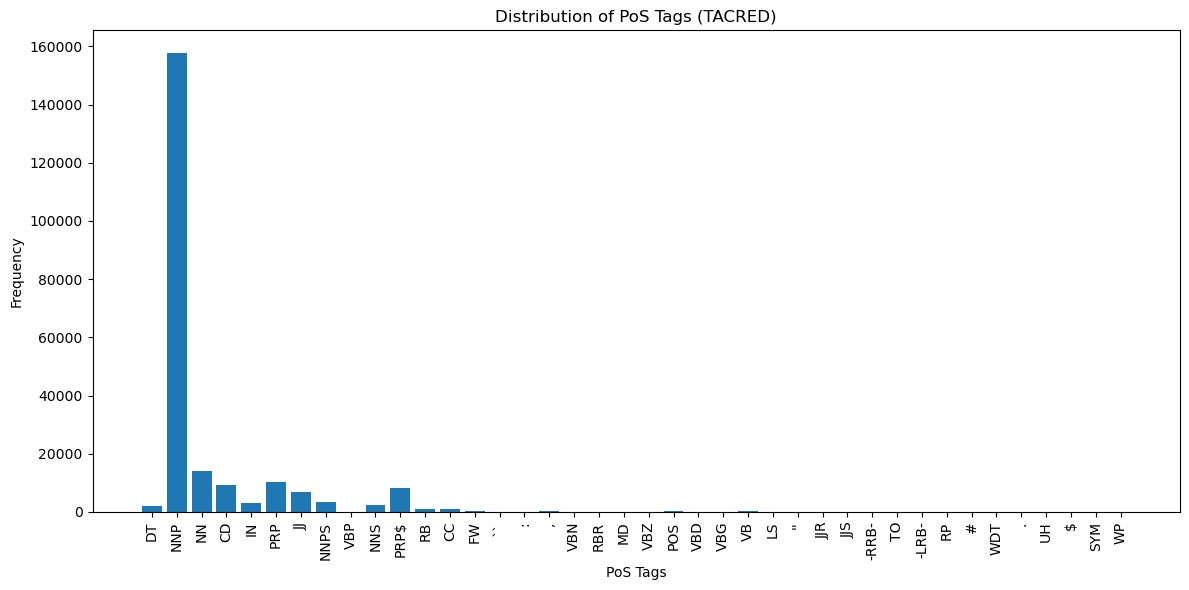

In [41]:
plt.figure(figsize=(12, 6));
plt.bar(tags, counts);
plt.xlabel("PoS Tags");
plt.ylabel("Frequency");
plt.title("Distribution of PoS Tags (TACRED)");
plt.xticks(rotation=90);
plt.tight_layout();
plt.show();

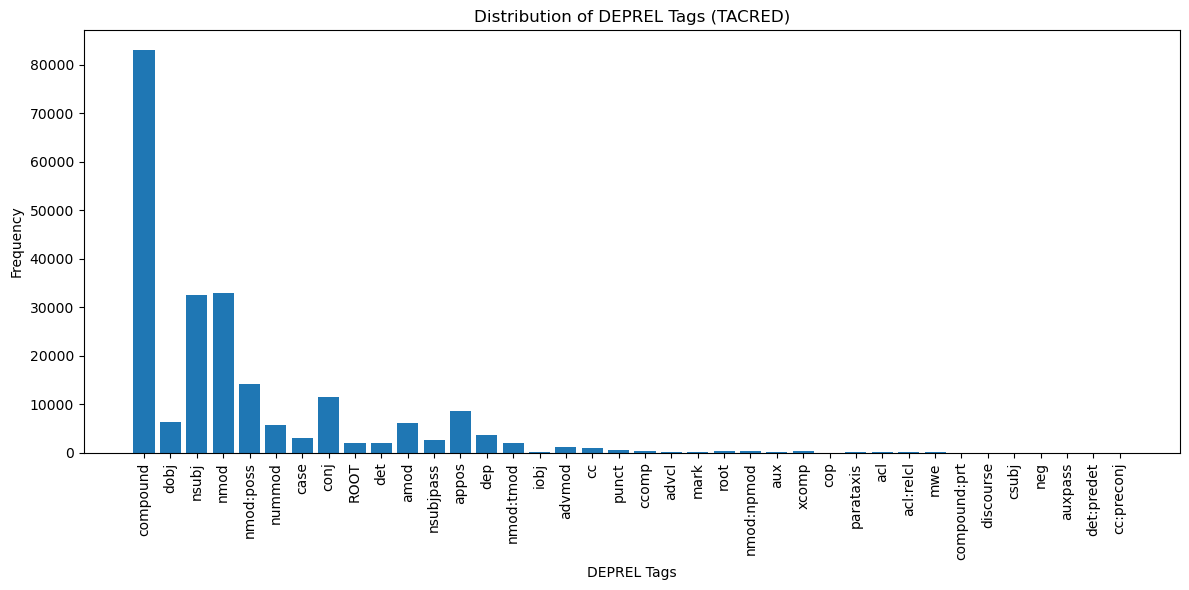

In [42]:
plt.figure(figsize=(12, 6));
plt.bar(deprel_tags, deprel_values);
plt.xlabel("DEPREL Tags");
plt.ylabel("Frequency");
plt.title("Distribution of DEPREL Tags (TACRED)");
plt.xticks(rotation=90);
plt.tight_layout();
plt.show();

#### Interim Discussion

Clearly, the PoS tags within TACRED are significantly skewed towards 'NNP', which may be in part explain the poor performance (possibly). However, looking at the DEPREL tags, its clear that there is less degree of skew. This could be an interesting point of investigation, but it may be the case that adding further syntactic properties of the sentences their its embeddings/encodings would simply be akin to adding noise. With that said, it may also be the case that it allows the model to learn these properties faster; and whilst we have seen some evidence of this under our experimental data, the scores are so closely aligned that any performance benefit may be considered negligible. Next, we perform the same approach to Re-TACRED.

In [44]:
with open("../../data/retacred/train.json") as file:
  retacred_data = json.load(file);

In [45]:
re_pos_count = Counter();
re_deprel_count = Counter();

for example in retacred_data:
  re_subject_pos_tags = example['stanford_pos'][example['subj_start'] : example['subj_end'] + 1];
  re_object_pos_tags = example['stanford_pos'][example['obj_start'] : example['obj_end'] + 1];
  re_subject_deprel_tags = example['stanford_deprel'][example['subj_start'] : example['subj_end'] + 1];
  re_object_deprel_tags = example['stanford_deprel'][example['obj_start'] : example['obj_end'] + 1];
  re_pos_count.update(re_subject_pos_tags);
  re_pos_count.update(re_object_pos_tags);
  re_deprel_count.update(re_subject_deprel_tags);
  re_deprel_count.update(re_object_deprel_tags);

retacred_tags = list(re_pos_count.keys());
retacred_counts = list(re_pos_count.values());
retacred_deprel_tags = list(re_deprel_count.keys());
retacred_deprel_values = list(re_deprel_count.values());

print(retacred_tags);
print(retacred_counts);

print(retacred_deprel_tags);
print(retacred_deprel_values);

['DT', 'NNP', 'NN', 'CD', 'IN', 'PRP', 'JJ', 'NNPS', 'VBP', 'NNS', 'PRP$', 'RB', 'CC', 'FW', '``', ':', 'VBN', ',', 'RBR', 'MD', 'POS', 'VBG', 'LS', "''", 'JJR', 'JJS', '-RRB-', 'VB', '-LRB-', 'TO', 'RP', 'VBZ', 'VBD', 'WDT', '#', 'UH', '.', 'WP', 'SYM']
[1912, 137357, 11291, 7939, 2474, 9356, 5356, 2548, 19, 1935, 7482, 873, 744, 48, 29, 81, 38, 251, 90, 13, 203, 73, 27, 27, 38, 8, 13, 72, 10, 13, 3, 17, 13, 1, 2, 2, 1, 3, 2]
['compound', 'dobj', 'nsubj', 'nmod', 'nmod:poss', 'nummod', 'case', 'conj', 'ROOT', 'det', 'amod', 'nsubjpass', 'appos', 'dep', 'nmod:tmod', 'iobj', 'advmod', 'cc', 'punct', 'ccomp', 'advcl', 'mark', 'root', 'nmod:npmod', 'aux', 'xcomp', 'acl:relcl', 'parataxis', 'mwe', 'acl', 'compound:prt', 'csubj', 'cop']
[71848, 5269, 28933, 28722, 12611, 4811, 2572, 9626, 1429, 1811, 4780, 2326, 7321, 2673, 1906, 150, 977, 743, 411, 187, 131, 27, 308, 235, 10, 275, 149, 54, 21, 43, 2, 2, 1]


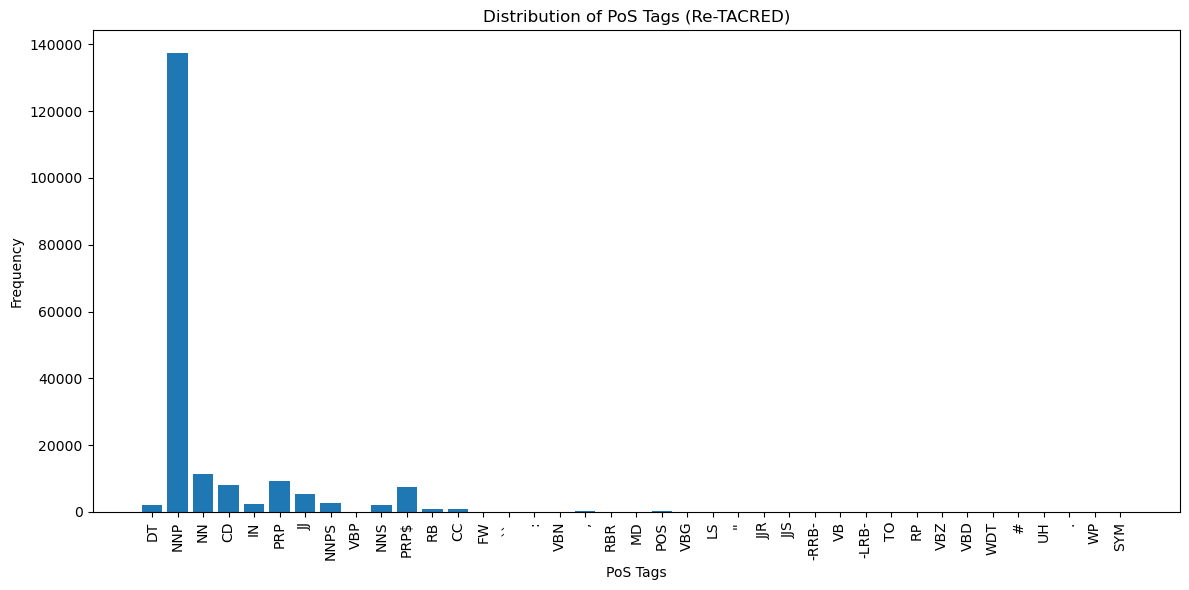

In [46]:
plt.figure(figsize=(12, 6));
plt.bar(retacred_tags, retacred_counts);
plt.xlabel("PoS Tags");
plt.ylabel("Frequency");
plt.title("Distribution of PoS Tags (Re-TACRED)");
plt.xticks(rotation=90);
plt.tight_layout();
plt.show();

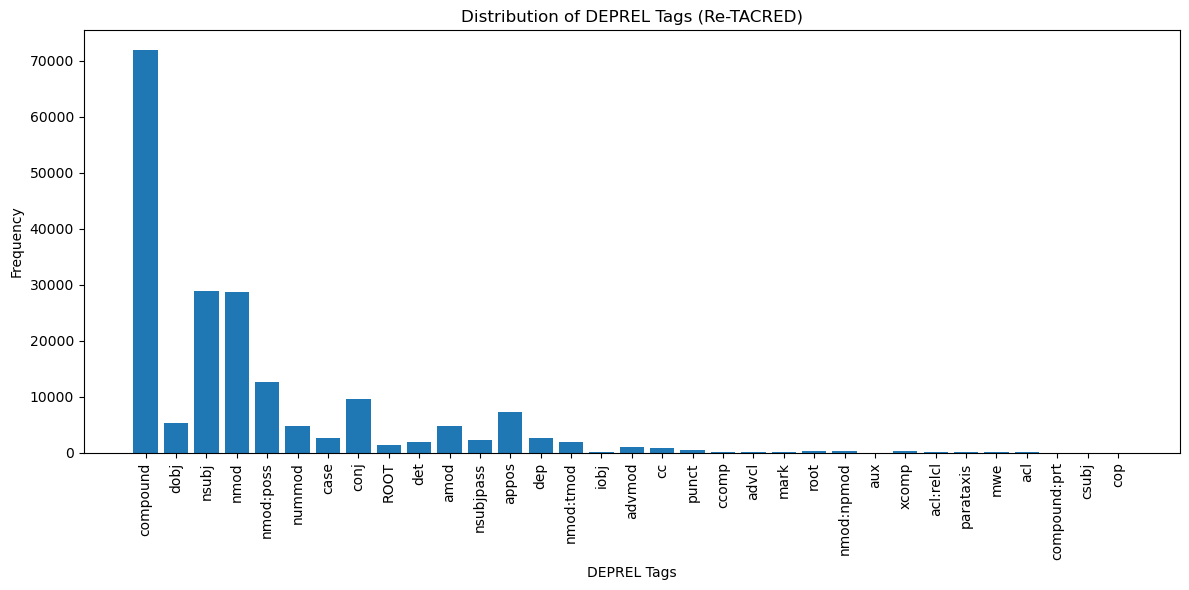

In [47]:
plt.figure(figsize=(12, 6));
plt.bar(retacred_deprel_tags, retacred_deprel_values);
plt.xlabel("DEPREL Tags");
plt.ylabel("Frequency");
plt.title("Distribution of DEPREL Tags (Re-TACRED)");
plt.xticks(rotation=90);
plt.tight_layout();
plt.show();

We see a very similar pattern/distribution of both PoS tags and DEPREL tags in Re-TACRED as compared to TACRED.